In [3]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Scanpy settings
sc.settings.verbosity = 3            # 0=errors, 1=warnings, 2=info, 3=hints
sc.set_figure_params(dpi=100, facecolor='white', figsize=(6, 5))
sc.settings.figdir = '../results/figures/'  # where plots are saved

# Results file path
results_file = '../results/pbmc3k.h5ad'

# Print package versions for reproducibility
# sc.logging.print_header()


In [4]:
import os
os.makedirs('../results/figures', exist_ok=True)
os.makedirs('../results', exist_ok=True)


# Download data if not already present
if not os.path.exists('../data/filtered_gene_bc_matrices'):
    os.makedirs('../data', exist_ok=True)
    print('Downloading PBMC3k dataset...')
    os.system('curl -o ../data/pbmc3k_filtered_gene_bc_matrices.tar.gz '
              'https://cf.10xgenomics.com/samples/cell/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz')
    os.system('tar -xzf ../data/pbmc3k_filtered_gene_bc_matrices.tar.gz -C ../data/')
    print('Done.')
else:
    print('Data already downloaded.')


Data already downloaded.


In [5]:
# Read the 10x MTX count matrix into AnnData
adata = sc.read_10x_mtx(
    '../data/filtered_gene_bc_matrices/hg19/',
    var_names='gene_symbols',   # use gene symbols as variable names
    cache=True,                 # write a cache file for faster re-reads
)

# Make gene names unique (some genes appear more than once in the matrix)
adata.var_names_make_unique()

print(adata)


... reading from cache file cache/..-data-filtered_gene_bc_matrices-hg19-matrix.h5ad
AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


In [6]:
# Flag mitochondrial genes (gene names starting with 'MT-')
adata.var['mt'] = adata.var_names.str.startswith('MT-')

# Calculate QC metrics
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=['mt'],
    percent_top=None,
    log1p=False,
    inplace=True
)

print('QC metrics calculated.')
print(adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].describe())

QC metrics calculated.
       n_genes_by_counts  total_counts  pct_counts_mt
count        2700.000000   2700.000000    2700.000000
mean          846.994074   2366.900391       2.215132
std           282.104964   1094.261963       1.165438
min           212.000000    548.000000       0.000000
25%           690.000000   1757.750000       1.536238
50%           817.000000   2197.000000       2.029639
75%           953.250000   2763.000000       2.640218
max          3422.000000  15844.000000      22.569027


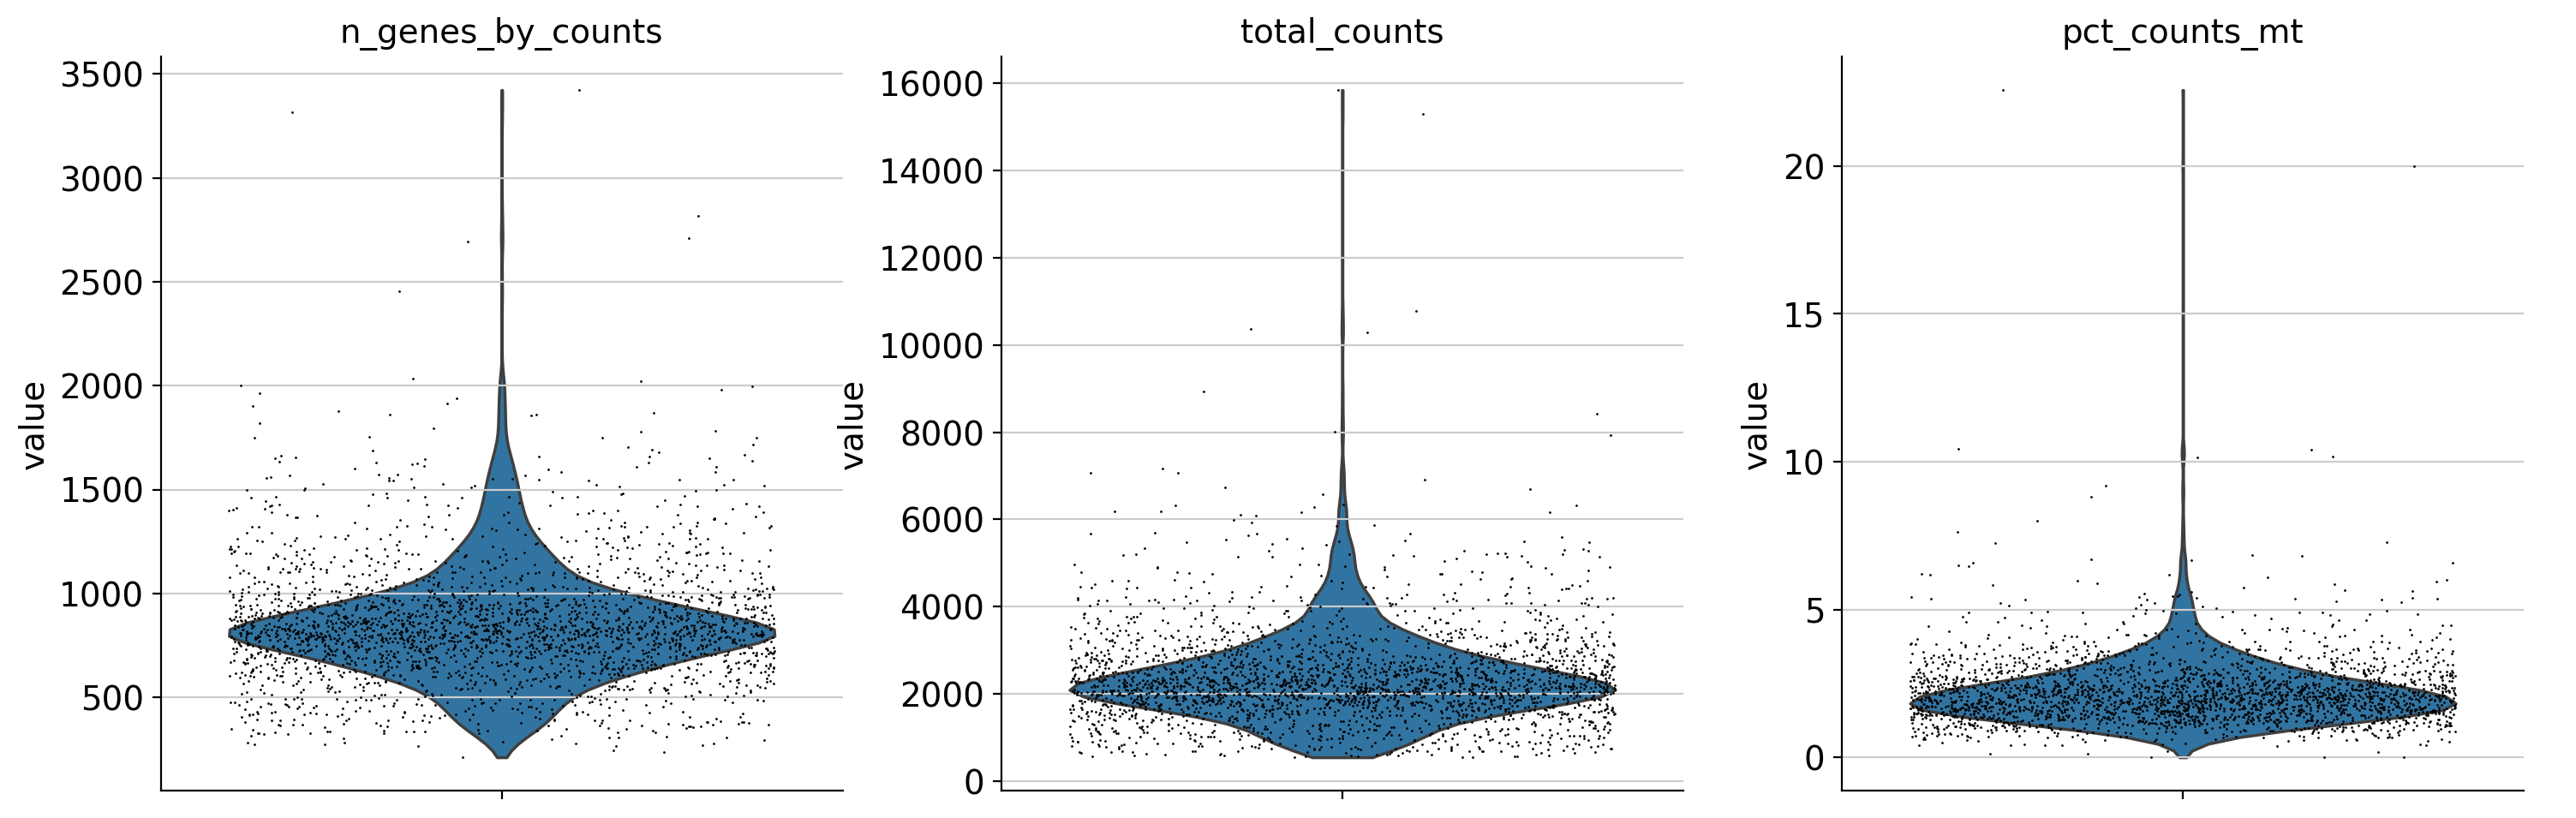

In [7]:
# Violin plots of QC metrics
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4,
    multi_panel=True,
    save='_qc_violin.png'
)


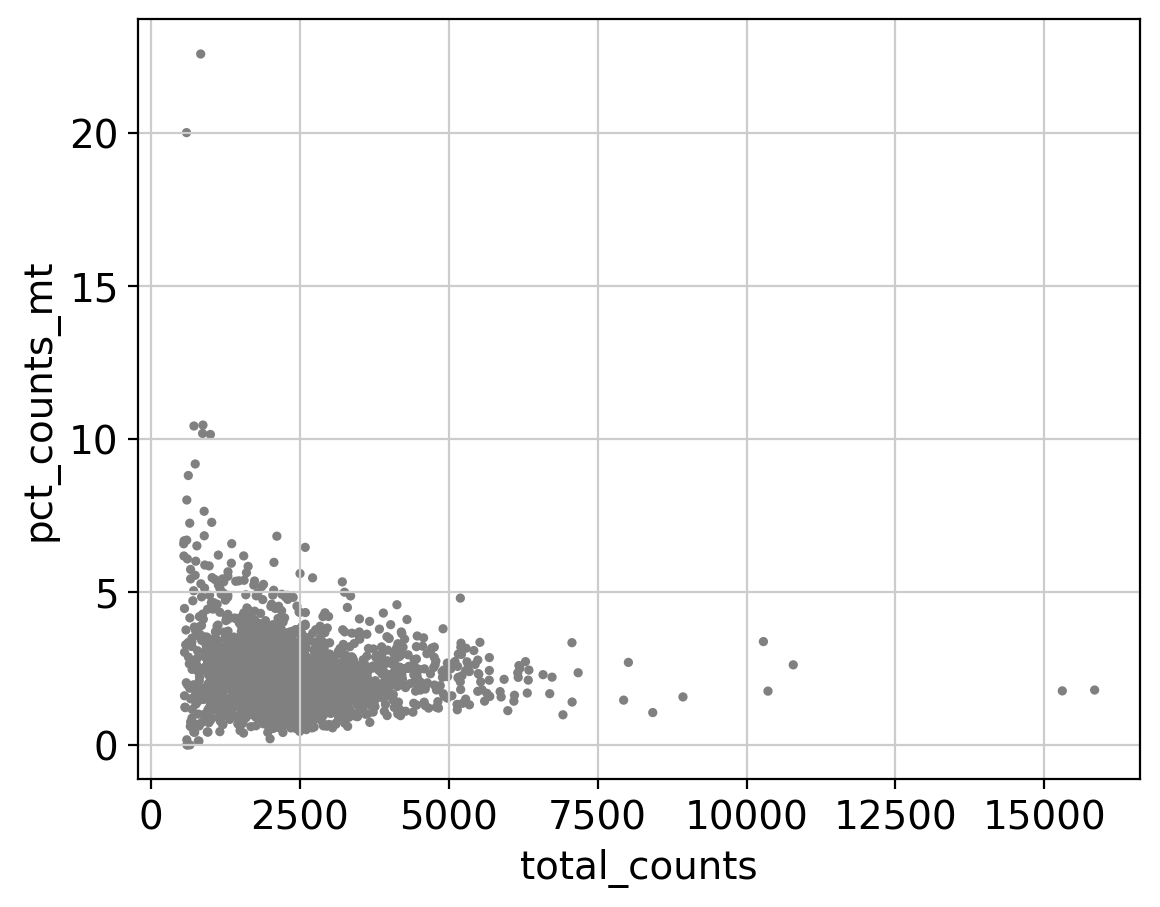

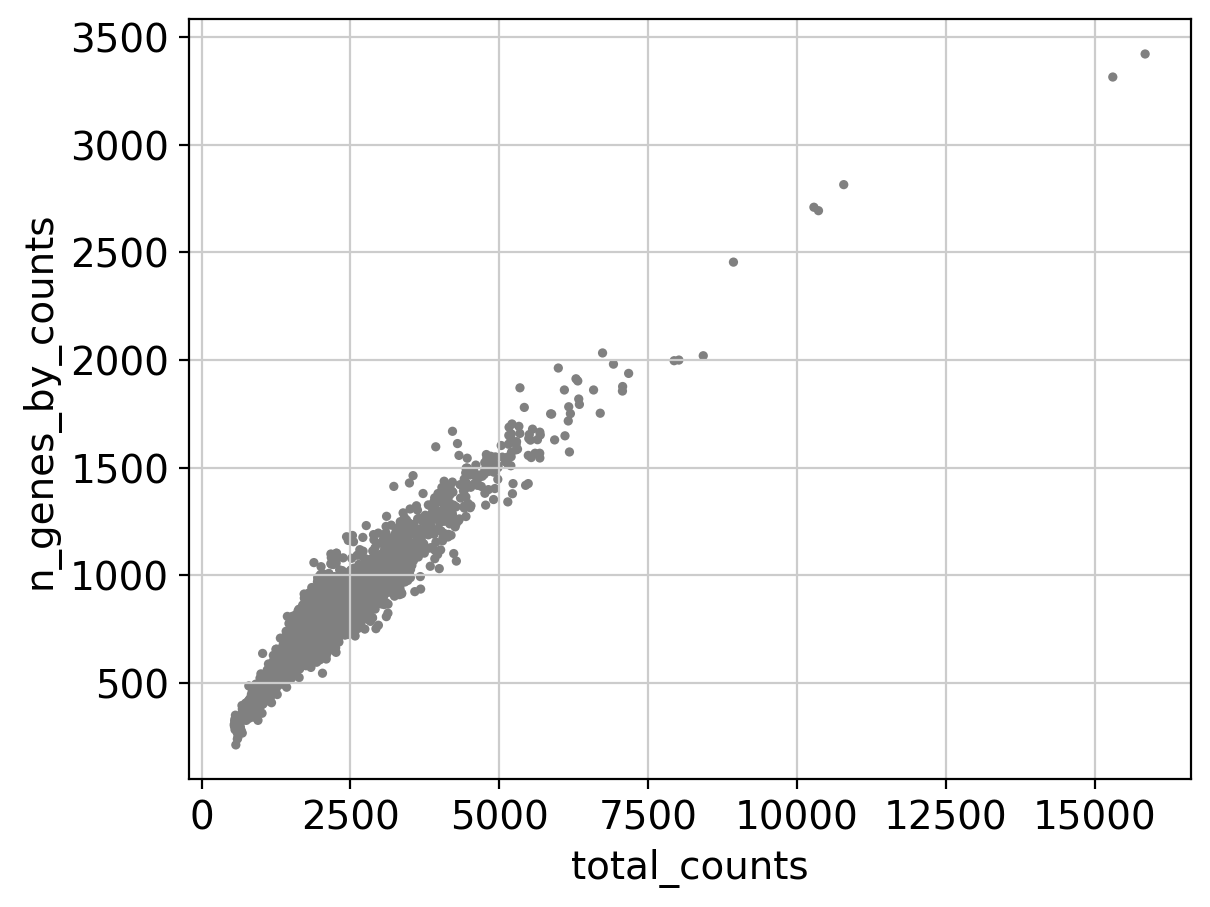

In [8]:
# Scatter plots: total counts vs genes coloured by MT%
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt', save='_mt_vs_counts.png')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', save='_genes_vs_counts.png')

In [9]:
# Apply QC filters
print(f'Cells before QC filtering: {adata.n_obs}')

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

adata = adata[adata.obs.n_genes_by_counts < 2500, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]

print(f'Cells after QC filtering:  {adata.n_obs}')
print(f'Genes after QC filtering:  {adata.n_vars}')

Cells before QC filtering: 2700
filtered out 19024 genes that are detected in less than 3 cells
Cells after QC filtering:  2638
Genes after QC filtering:  13714


In [10]:
# Normalise each cell to 10,000 total counts
sc.pp.normalize_total(adata, target_sum=1e4)

# Log-transform: log(x + 1)
sc.pp.log1p(adata)

# Freeze normalised counts in the raw attribute
adata.raw = adata

print('Normalisation complete. Raw counts frozen.')

normalizing counts per cell
    finished (0:00:04)
Normalisation complete. Raw counts frozen.


extracting highly variable genes
    finished (0:00:02)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


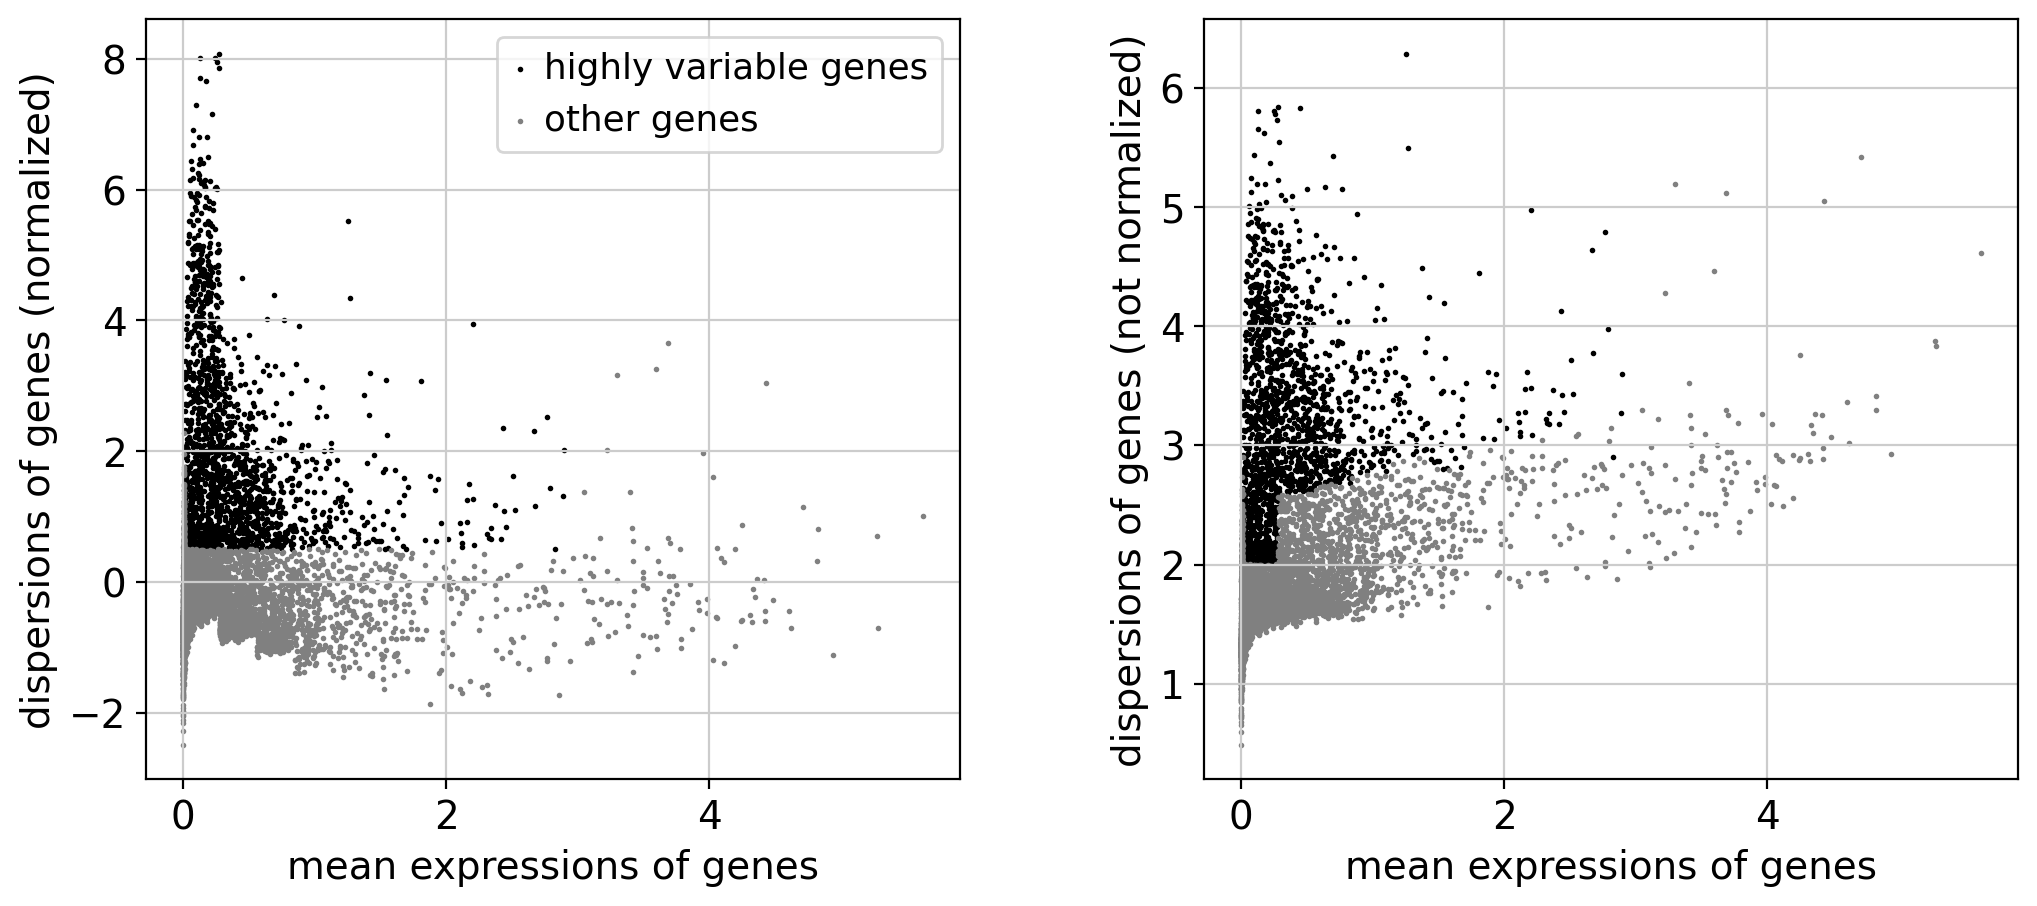

Highly variable genes: 1838 / 13714


In [11]:
# Identify highly variable genes
sc.pp.highly_variable_genes(
    adata,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5,
)

# Plot HVGs
sc.pl.highly_variable_genes(adata, save='_hvg.png')

print(f'Highly variable genes: {adata.var.highly_variable.sum()} / {adata.n_vars}')

In [12]:
# Keep only HVGs for downstream analysis
adata = adata[:, adata.var.highly_variable]

# Regress out confounders: total counts and MT percentage
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])

# Scale to unit variance, clip at 10 standard deviations
sc.pp.scale(adata, max_value=10)

print(f'AnnData after feature selection: {adata.shape}')

regressing out ['total_counts', 'pct_counts_mt']
    sparse input is densified and may lead to high memory use
    finished (0:00:00)
AnnData after feature selection: (2638, 1838)


computing PCA
    with n_comps=50
    finished (0:00:01)


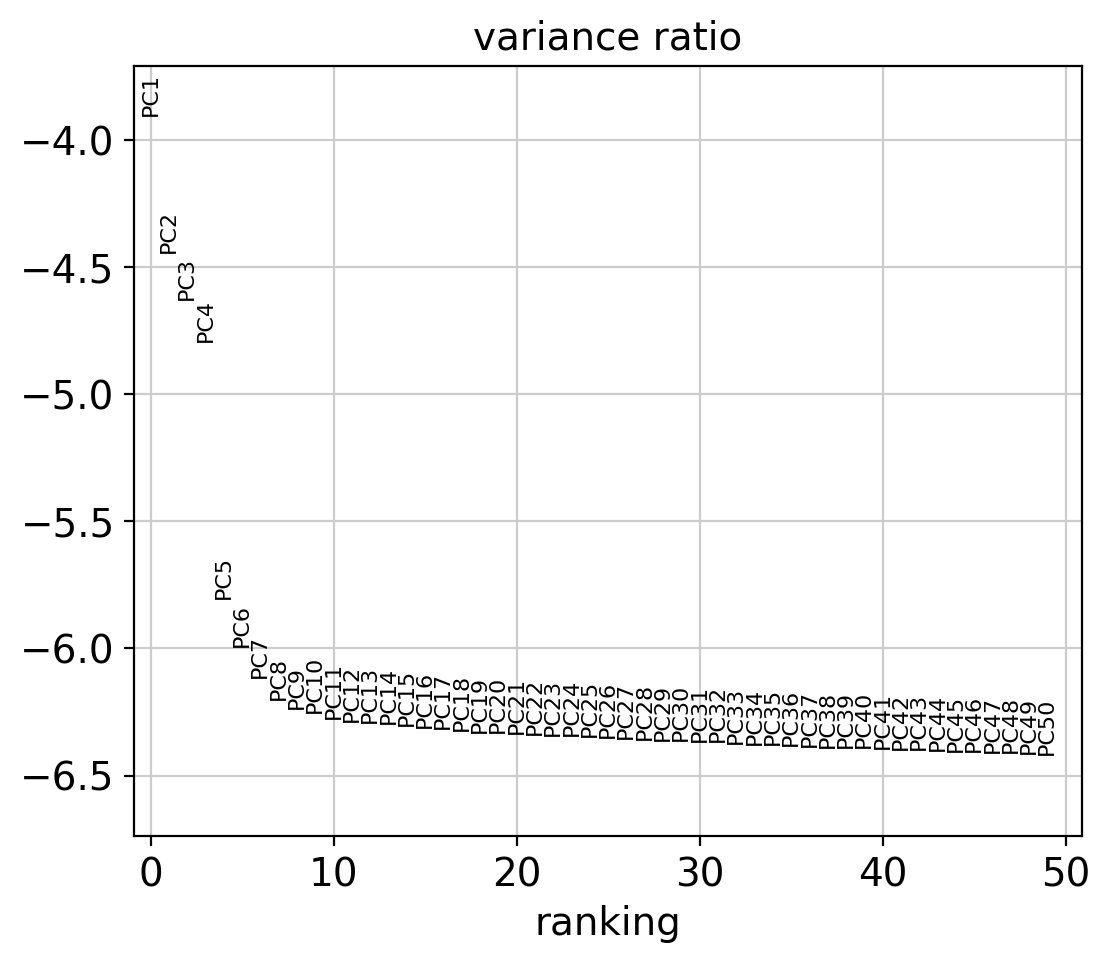

In [13]:
# PCA
sc.tl.pca(adata, svd_solver='arpack', n_comps=50)

# Variance ratio plot (elbow plot) — used to decide how many PCs to use
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50, save='_pca_variance.png')

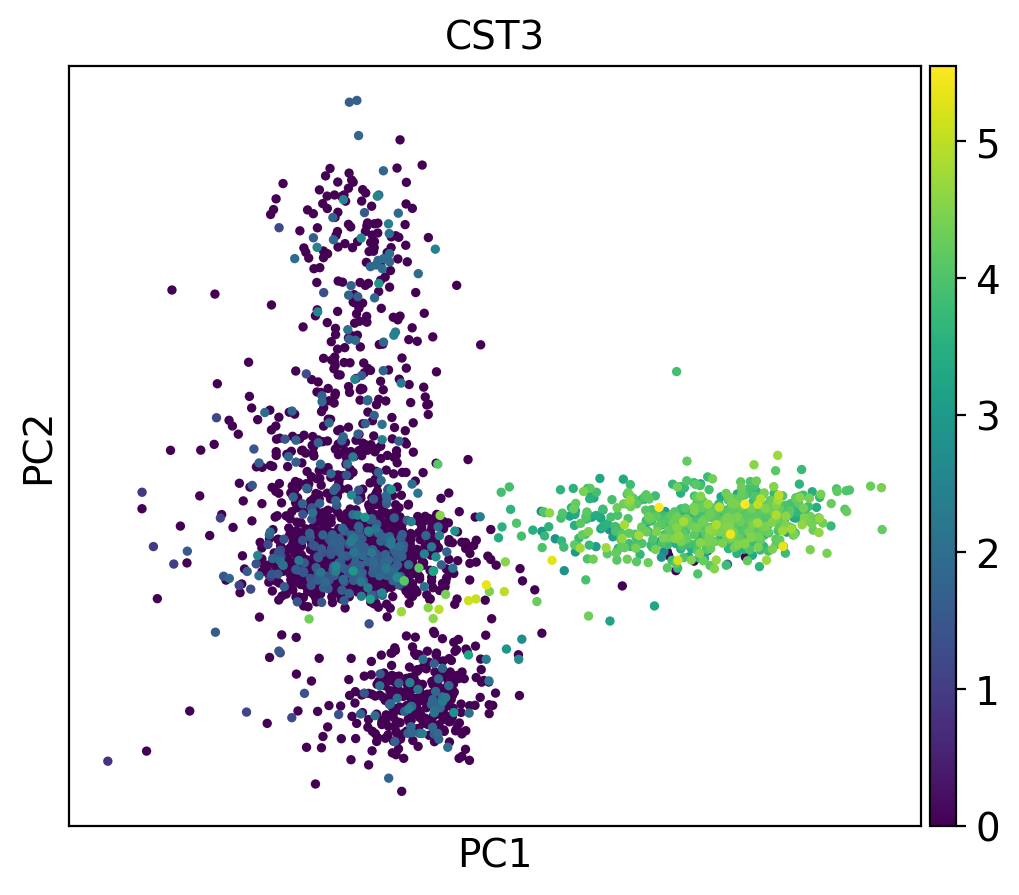

In [14]:
# PCA scatter plot
sc.pl.pca(adata, color='CST3', save='_pca_CST3.png')

In [15]:
# Build k-NN neighbourhood graph
# Using 40 PCs based on the elbow plot — captures biological signal without noise
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

print('k-NN graph computed.')

computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:24)
k-NN graph computed.


In [16]:
# UMAP embedding
sc.tl.umap(adata)

# t-SNE embedding
sc.tl.tsne(adata)

print('UMAP and t-SNE computed.')

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:05)
computing tSNE
    using 'X_pca' with n_pcs = 50
    using sklearn.manifold.TSNE
    finished: added
    'X_tsne', tSNE coordinates (adata.obsm)
    'tsne', tSNE parameters (adata.uns) (0:00:32)
UMAP and t-SNE computed.


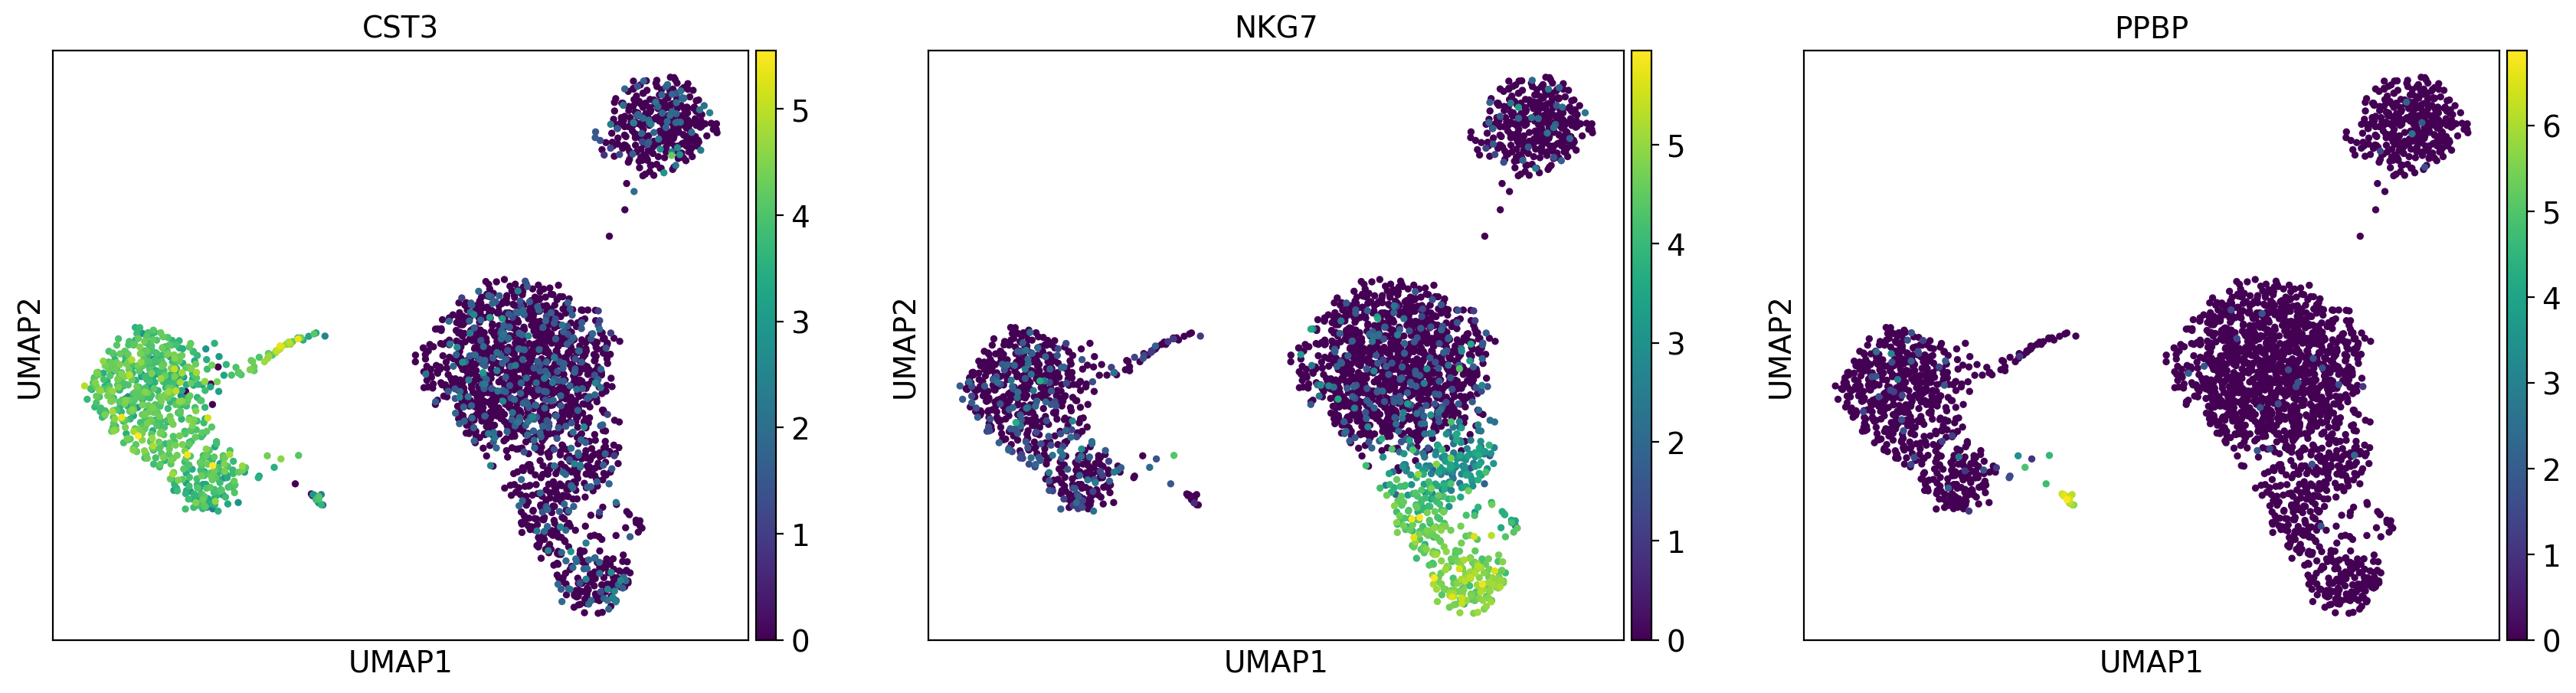

In [17]:
# Visualise UMAP coloured by known marker genes (before clustering)
sc.pl.umap(
    adata,
    color=['CST3', 'NKG7', 'PPBP'],
    save='_umap_markers_preclustering.png'
)

In [18]:
!ls

cache  sample_data


In [ ]:
!pip install -q scanpy anndata python-igraph louvain

import numpy as np
import scanpy as sc

# Load example dataset (since you currently have no file)
adata = sc.datasets.pbmc3k()

# Preprocessing
sc.pp.pca(adata)
sc.pp.neighbors(adata)

# Louvain clustering
sc.tl.louvain(adata)

print(f'Clusters identified: {adata.obs["louvain"].nunique()}')
print(adata.obs["louvain"].value_counts())

# UMAP coloured by Louvain cluster
sc.pl.umap(adata, color='louvain', save='_umap_louvain.png')

# t-SNE coloured by Louvain cluster
sc.pl.tsne(adata, color='louvain', save='_tsne_louvain.png')


/usr/local/lib/python3.12/dist-packages/legacy_api_wrap/__init__.py:88: FutureWarning: Use `scanpy.tl.leiden` instead
  return fn(*args_all, **kw)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 33.7 MB/s eta 0:00:00


/tmp/ipykernel_33800/348534992.py:17: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata)


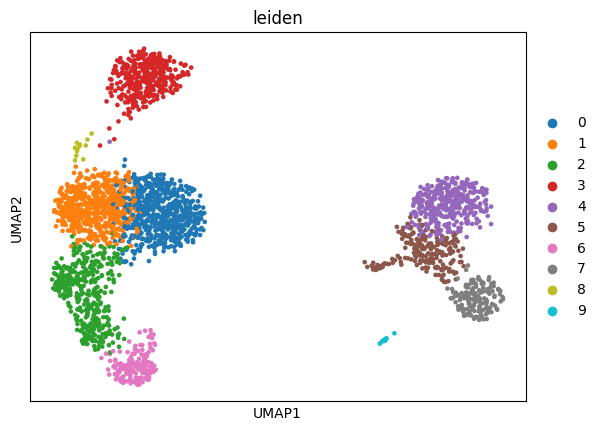

Results saved to results.h5ad
AnnData object with n_obs × n_vars = 2700 × 2000
    obs: 'leiden'
    var: 'gene_ids', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


In [8]:
!pip install -q scanpy anndata python-igraph leidenalg

import scanpy as sc

# Load example dataset
adata = sc.datasets.pbmc3k()

# Preprocessing
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var["highly_variable"]].copy()

# PCA + neighbors + clustering + UMAP
sc.pp.pca(adata, n_comps=30)
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30)
sc.tl.leiden(adata)
sc.tl.umap(adata)

# Plot UMAP
sc.pl.umap(adata, color="leiden")

# Save result
results_file = "results.h5ad"
adata.write(results_file)

print(f"Results saved to {results_file}")
print(adata)

In [9]:
!ls

cache  data  results.h5ad  sample_data


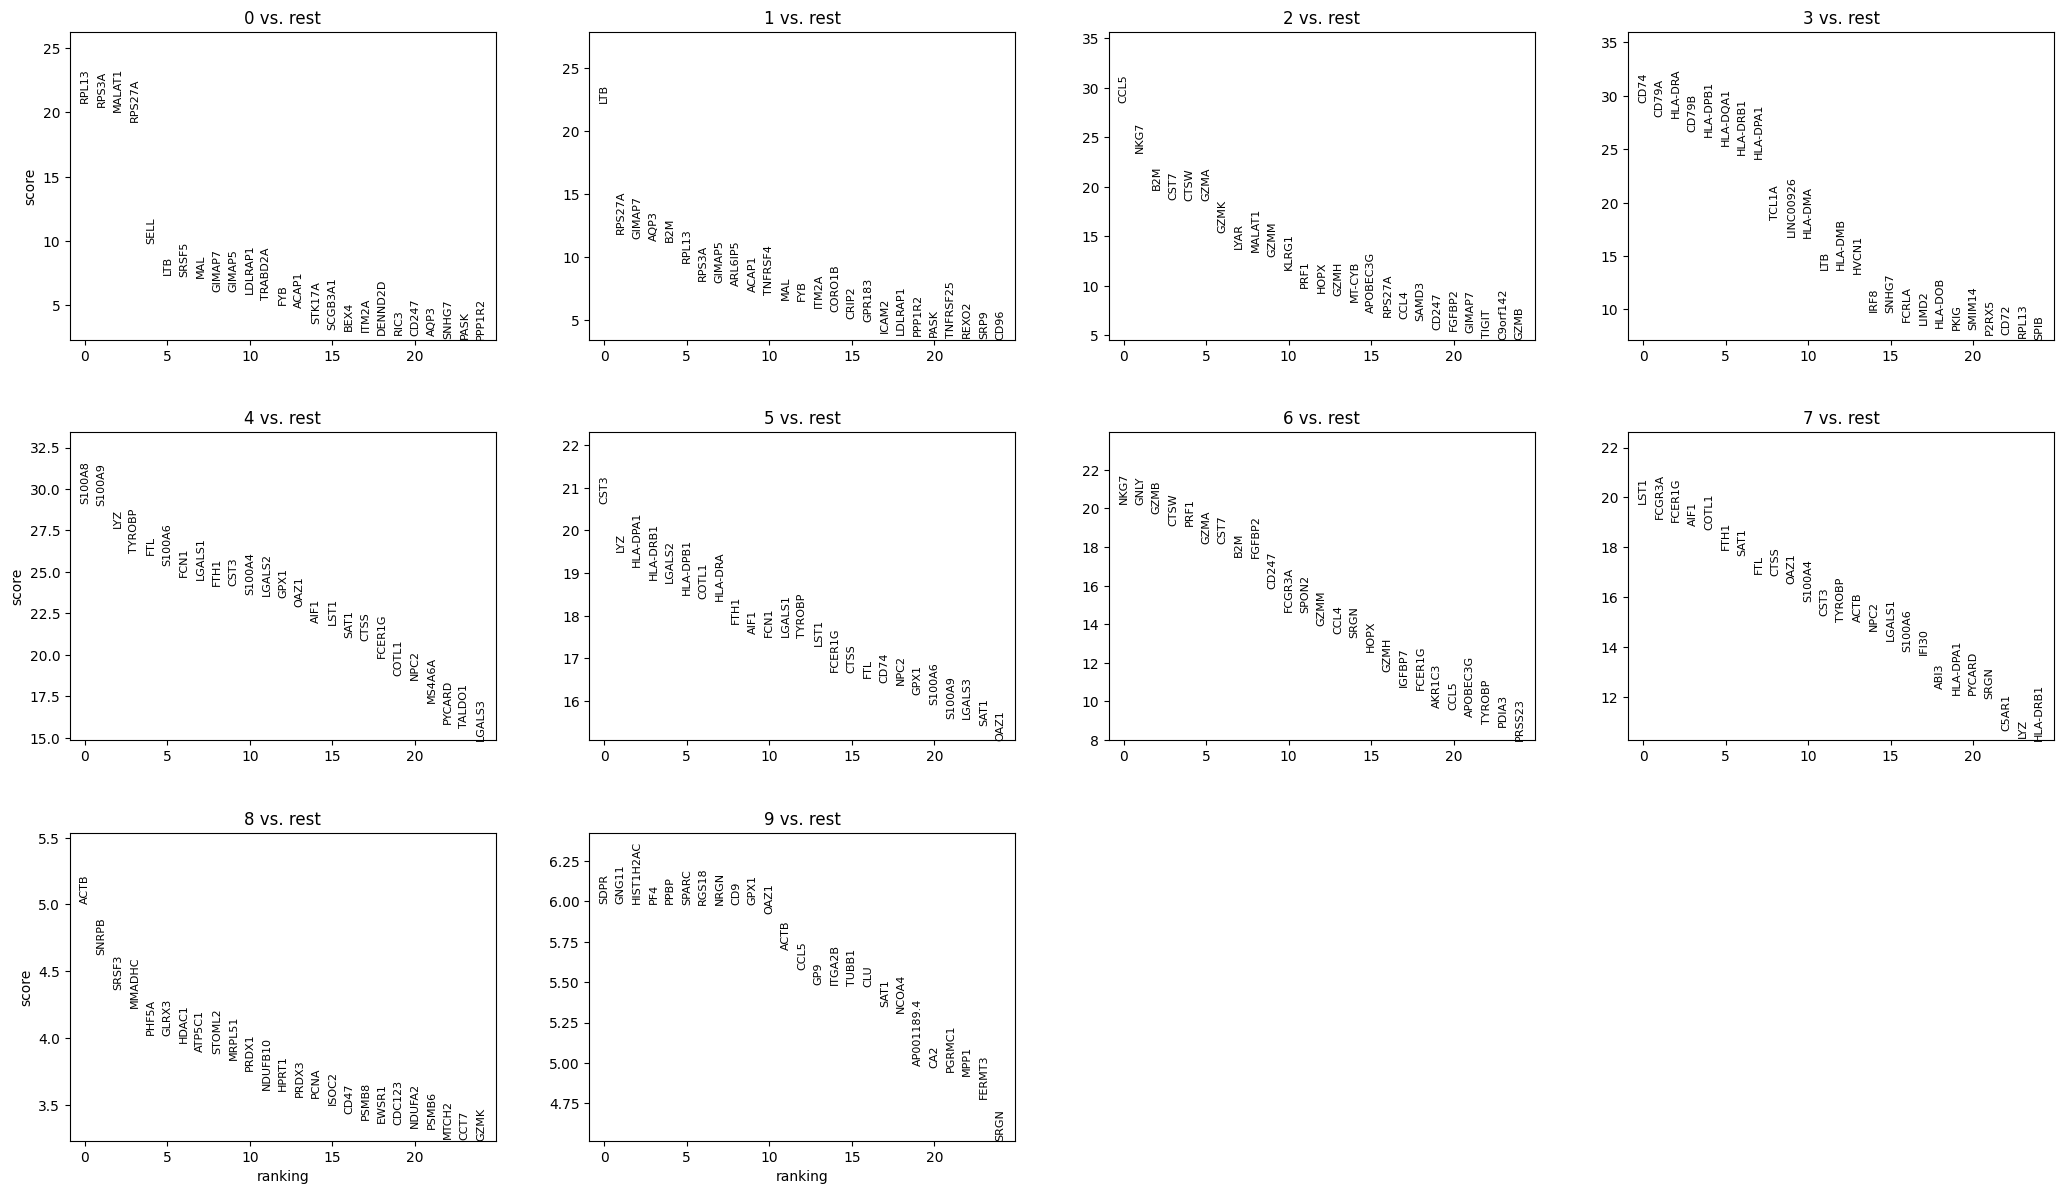

Top 10 marker genes per cluster:
        0        1       2          3       4         5       6       7       8          9
0   RPL13      LTB    CCL5       CD74  S100A8      CST3    NKG7    LST1    ACTB       SDPR
1   RPS3A   RPS27A    NKG7      CD79A  S100A9       LYZ    GNLY  FCGR3A   SNRPB      GNG11
2  MALAT1   GIMAP7     B2M    HLA-DRA     LYZ  HLA-DPA1    GZMB  FCER1G   SRSF3  HIST1H2AC
3  RPS27A     AQP3    CST7      CD79B  TYROBP  HLA-DRB1    CTSW    AIF1  MMADHC        PF4
4    SELL      B2M    CTSW   HLA-DPB1     FTL    LGALS2    PRF1   COTL1   PHF5A       PPBP
5     LTB    RPL13    GZMA   HLA-DQA1  S100A6  HLA-DPB1    GZMA    FTH1   GLRX3      SPARC
6   SRSF5    RPS3A    GZMK   HLA-DRB1    FCN1     COTL1    CST7    SAT1   HDAC1      RGS18
7     MAL   GIMAP5    LYAR   HLA-DPA1  LGALS1   HLA-DRA     B2M     FTL  ATP5C1       NRGN
8  GIMAP7  ARL6IP5  MALAT1      TCL1A    FTH1      FTH1  FGFBP2    CTSS  STOML2        CD9
9  GIMAP5    ACAP1    GZMM  LINC00926    CST3      AIF1  

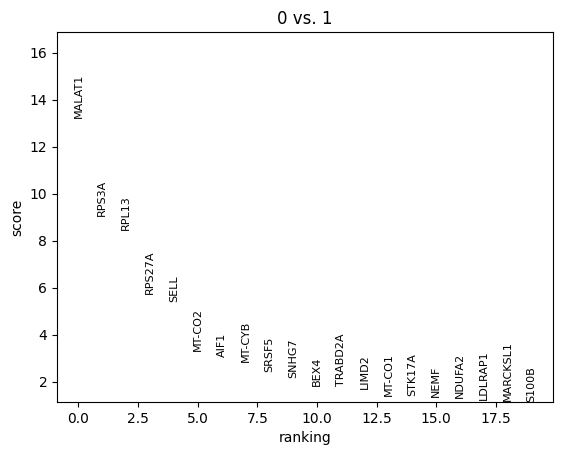

In [10]:
import pandas as pd
import scanpy as sc

# Marker gene identification
# Use "leiden" if your clustering column is leiden
cluster_key = "leiden"

sc.tl.rank_genes_groups(
    adata,
    groupby=cluster_key,
    method="wilcoxon"
)

# Plot top 25 marker genes per cluster
sc.pl.rank_genes_groups(
    adata,
    n_genes=25,
    sharey=False
)

# Show top 10 marker genes per cluster as table
marker_df = pd.DataFrame(
    adata.uns["rank_genes_groups"]["names"]
).head(10)

print("Top 10 marker genes per cluster:")
print(marker_df.to_string())

# Compare cluster 0 against cluster 1
sc.tl.rank_genes_groups(
    adata,
    groupby=cluster_key,
    groups=["0"],
    reference="1",
    method="wilcoxon"
)

sc.pl.rank_genes_groups(
    adata,
    groups=["0"],
    n_genes=20
)

# Re-run on all clusters after comparison
sc.tl.rank_genes_groups(
    adata,
    groupby=cluster_key,
    method="wilcoxon"
)

In [12]:
# ---- Save results ----

results_file = "results.h5ad"   # you can change the name if you want

adata.write(results_file)

print(f"Results saved to ./{results_file}")
print(adata)

Results saved to ./results.h5ad
AnnData object with n_obs × n_vars = 2700 × 2000
    obs: 'leiden'
    var: 'gene_ids', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


In [13]:
!ls

cache  data  results.h5ad  sample_data
